In [ ]:
# ==========================================
# 1. MANIPULACIÓN, PROCESAMIENTO Y ENTORNO
# ==========================================
import os
import re
import numpy as np
import pandas as pd
from scipy import stats

# ==========================================
# 2. PREPROCESAMIENTO Y TRANSFORMACIÓN (ML)
# ==========================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ==========================================
# 3. DETECCIÓN DE ANOMALÍAS Y OUTLIERS
# ==========================================
from sklearn.ensemble import IsolationForest

# ==========================================
# 4. MODELADO Y EVALUACIÓN: REGRESIÓN
# ==========================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor

# ==========================================
# 5. MODELADO Y EVALUACIÓN: CLASIFICACIÓN
# ==========================================
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 6. VISUALIZACIÓN DE DATOS (ESTÁTICA E INTERACTIVA)
# ==========================================
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

# ==========================================
# 7. PERSISTENCIA DE MODELOS (GUARDADO)
# ==========================================
import joblib
df = pd.read_csv('data/fake_job_postings.csv')
print(df.shape)
print(df.head())

(17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         descripti

In [2]:
# Eliminar columnas que no aportan información al modelo
columnas_a_eliminar = ['job_id'] # El ID es solo un contador
df = df.drop(columns=columnas_a_eliminar)

In [3]:
# Rellenar nulos en columnas categóricas y de texto
categoricas_y_texto = ['department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

for col in categoricas_y_texto:
    df[col] = df[col].fillna('Unspecified')

In [4]:
def limpiar_texto(texto):
    if pd.isna(texto) or texto == 'Unspecified':
        return ''
    texto = str(texto).lower() # Todo a minúsculas
    texto = re.sub(r'[^a-z0-9\s]', '', texto) # Quitar caracteres especiales (deja solo letras, números y espacios)
    texto = re.sub(r'\s+', ' ', texto).strip() # Limpiar espacios dobles o saltos de línea
    return texto

# Ejemplo: Aplicar la limpieza a la columna 'description'
df['description_clean'] = df['description'].apply(limpiar_texto)

In [5]:
# Extraer el código del país (los dos primeros caracteres antes de la primera coma)
df['country'] = df['location'].apply(lambda x: str(x).split(',')[0].strip() if pd.notna(x) else 'Unspecified')

In [6]:
# Ver la distribución de clases
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True) * 100)

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


In [7]:
# 1. Comprobar que ya no quedan nulos en las columnas que vas a usar
print(df[['title', 'description_clean', 'country', 'fraudulent']].isnull().sum())

# 2. Ver cómo ha quedado una fila real tras la limpieza
print(df['description_clean'].iloc[0][:300]) # Muestra los primeros 300 caracteres de la primera descripción

title                0
description_clean    0
country              0
fraudulent           0
dtype: int64
food52 a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing full and parttime unpaid interns to work in a small team of editors executives and developers in its new york city headquartersreproducing andor repackaging existing 


In [8]:
print(df.columns)

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'description_clean', 'country'],
      dtype='str')


# **Outliers**

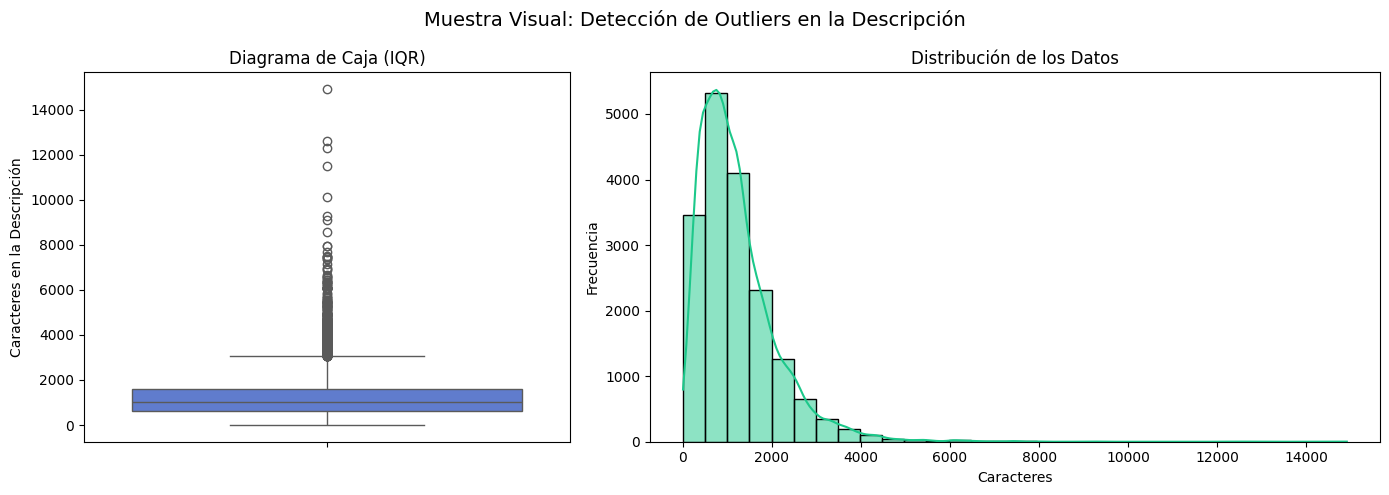

📊 Estadísticas de control:
count    17880.000000
mean      1218.005034
std        894.827787
min          6.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: longitud_descripcion, dtype: float64


In [9]:
# Crear la métrica de longitud de texto
df["longitud_descripcion"] = df["description"].fillna("").str.len()

# Configurar gráficos
fig, (ax_box, ax_hist) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": (0.4, 0.6)}
)
fig.suptitle(
    "Muestra Visual: Detección de Outliers en la Descripción", fontsize=14
)

# 1. Boxplot (Muestra los puntos atípicos fuera de los bigotes)
sns.boxplot(ax=ax_box, y=df["longitud_descripcion"], color="#4e73df")
ax_box.set_title("Diagrama de Caja (IQR)")
ax_box.set_ylabel("Caracteres en la Descripción")

# 2. Histograma (Muestra la distribución real)
sns.histplot(
    ax=ax_hist, x=df["longitud_descripcion"], bins=30, kde=True, color="#1cc88a")
ax_hist.set_title("Distribución de los Datos")
ax_hist.set_xlabel("Caracteres")
ax_hist.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Resumen numérico en consola
print("📊 Estadísticas de control:")
print(df["longitud_descripcion"].describe())

In [10]:
total_original = df.shape[0]

# 2. Calcular la métrica temporal
df["_len_desc"] = df["description"].fillna("").str.len()

# 3. Aplicar el filtro del Rango Intercuartílico (IQR)
Q1 = df["_len_desc"].quantile(0.25)
Q3 = df["_len_desc"].quantile(0.75)
IQR = Q3 - Q1

# Definir límites (El estándar es 1.5 veces el IQR)
limite_inferior = max(
    10, Q1 - 1.5 * IQR
)  # Evitamos longitudes negativas, exigimos al menos 10 caracteres
limite_superior = Q3 + 1.5 * IQR

# 4. Filtrar el DataFrame
df_limpio = df[(df["_len_desc"] >= limite_inferior) & (df["_len_desc"] <= limite_superior)].copy()

# Eliminar la columna auxiliar
df_limpio.drop(columns=["_len_desc"], inplace=True)

# 5. Guardar resultados
outliers_eliminados = total_original - df_limpio.shape[0]
print(f"🧹 ¡Limpieza completada!")
print(f"🔹 Filas originales: {total_original}")
print(f"🔹 Outliers eliminados: {outliers_eliminados}")
print(f"🔹 Filas actuales: {df_limpio.shape[0]}")

output_path = os.path.join("data", "fake_job_postings_clean.csv")
df_limpio.to_csv(output_path, index=False)
print(f"💾 Guardado en: {output_path}")

df_clean = df_limpio.copy()

🧹 ¡Limpieza completada!
🔹 Filas originales: 17880
🔹 Outliers eliminados: 727
🔹 Filas actuales: 17153
💾 Guardado en: data\fake_job_postings_clean.csv


## Analisis Univariado

In [11]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 17153 entries, 0 to 17879
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   title                 17153 non-null  str  
 1   location              16820 non-null  str  
 2   department            17153 non-null  str  
 3   salary_range          17153 non-null  str  
 4   company_profile       17153 non-null  str  
 5   description           17153 non-null  str  
 6   requirements          17153 non-null  str  
 7   benefits              17153 non-null  str  
 8   telecommuting         17153 non-null  int64
 9   has_company_logo      17153 non-null  int64
 10  has_questions         17153 non-null  int64
 11  employment_type       17153 non-null  str  
 12  required_experience   17153 non-null  str  
 13  required_education    17153 non-null  str  
 14  industry              17153 non-null  str  
 15  function              17153 non-null  str  
 16  fraudulent          

fraudulent
0    16330
1      823
Name: count, dtype: int64


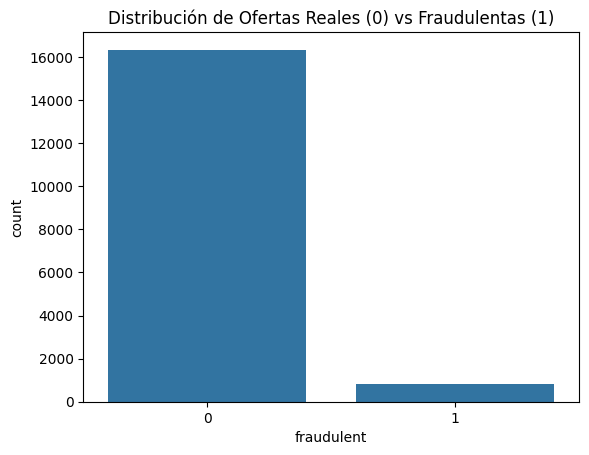

In [12]:
print(df_clean["fraudulent"].value_counts())
sns.countplot(x="fraudulent", data=df_clean)
plt.title("Distribución de Ofertas Reales (0) vs Fraudulentas (1)")
plt.show()

required_experience
Unspecified         6740
Mid-Senior level    3623
Entry level         2654
Associate           2209
Not Applicable      1087
Internship           376
Director             337
Executive            127
Name: count, dtype: int64


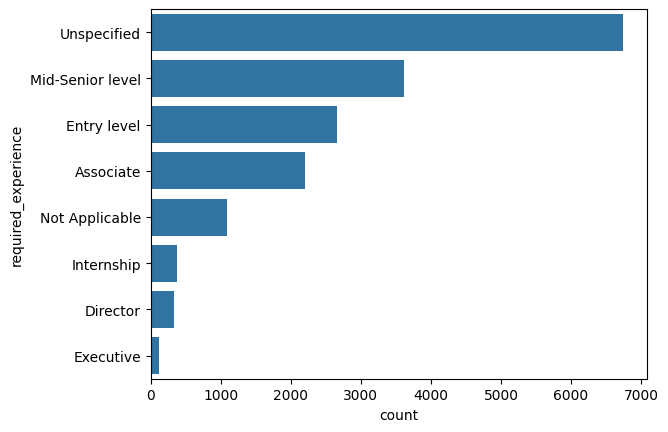

In [13]:
# Ver los valores únicos de la experiencia
print(df_clean['required_experience'].value_counts(dropna=False))

# Gráfico de barras horizontal por si hay muchas categorías
sns.countplot(y='required_experience', data=df_clean, order=df_clean['required_experience'].value_counts().index)
plt.show()

In [14]:
#Creamos una columna que rellenamos donde rellenamos nulos con texto vacío, aseguramos que sea string y medimos la longitud

df_clean['description_length'] = df_clean['description_clean'].str.len().fillna(0)

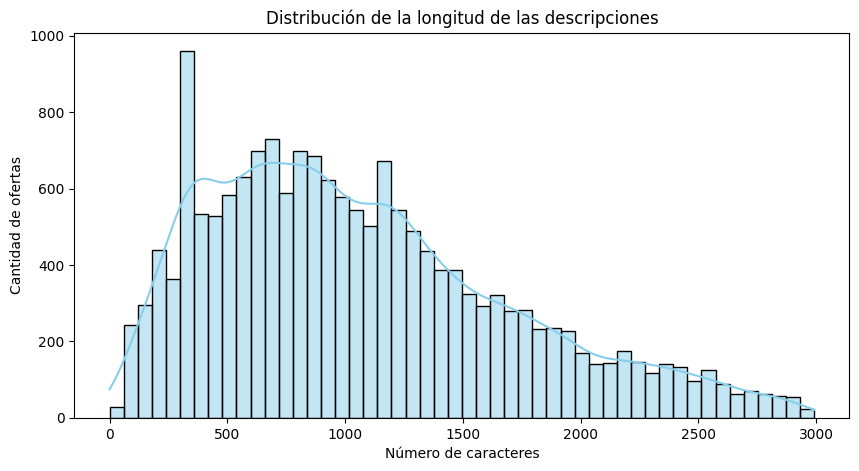

In [15]:
# Pintamos el histograma
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['description_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de la longitud de las descripciones')
plt.xlabel('Número de caracteres')
plt.ylabel('Cantidad de ofertas')
plt.show()

C:\Users\felix\AppData\Local\Temp\ipykernel_18296\528067482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='industry', data=df_clean, order=df_clean['industry'].value_counts().iloc[:10].index, palette='mako')


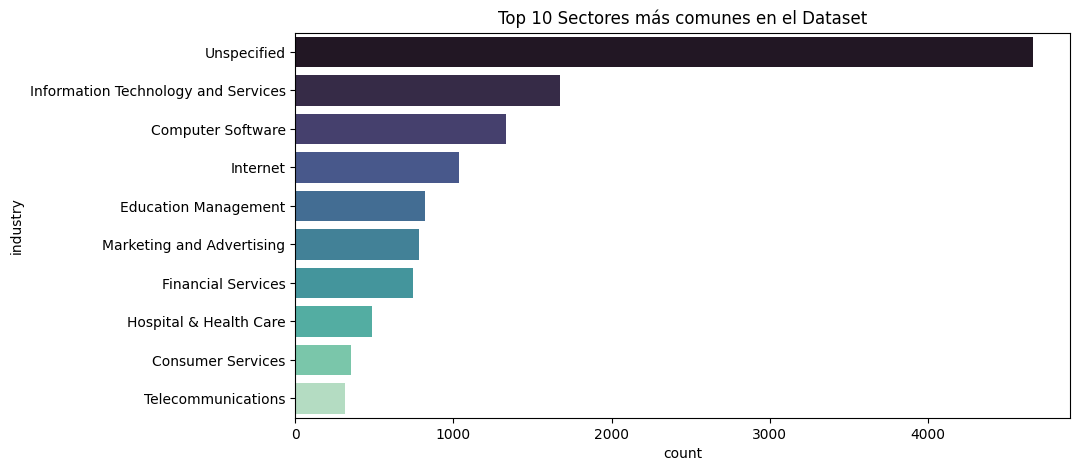

In [16]:
# Ver los 10 sectores con más ofertas de empleo
plt.figure(figsize=(10, 5))
sns.countplot(y='industry', data=df_clean, order=df_clean['industry'].value_counts().iloc[:10].index, palette='mako')
plt.title('Top 10 Sectores más comunes en el Dataset')
plt.show()

## 📝 Conclusiones del Análisis Univariado

Tras analizar de forma individual las variables clave de nuestro dataset de ofertas de empleo, hemos extraído las siguientes conclusiones fundamentales para el desarrollo del proyecto:

### 1. Desbalanceo Crítico de la Variable Objetivo (`fraudulent`)
* **Hallazgo:** El dataset presenta un desbalanceo masivo. Las ofertas de trabajo fraudulentas representan únicamente alrededor del **5%** del total de los registros, mientras que el 95% restante corresponde a ofertas reales.
* **Impacto en el modelo:** Este desbalanceo nos indica que **no podremos utilizar la métrica de *Accuracy* (Exactitud)** como indicador principal para evaluar nuestros modelos predictivos. Un clasificador básico que prediga siempre "no fraude" obtendría un 95% de acierto pero sería completamente inútil. Deberemos enfocar los esfuerzos en optimizar métricas como el **Recall** (Sensibilidad) y el **F1-Score** para capturar correctamente ese 5% de casos positivos.

### 2. Comportamiento de las Variables Binarias e Indicadores
* **`telecommuting` (Teletrabajo):** La inmensa mayoría de las ofertas publicadas corresponden a puestos presenciales. El trabajo en remoto es una opción muy minoritaria en la distribución general del dataset.
* **`has_company_logo` (Logo de la empresa):** Predominan notablemente las ofertas que sí cuentan con un logotipo de empresa subido a la plataforma, lo que sugiere que la falta de este elemento podría ser una anomalía a investigar.
* **`has_questions` (Preguntas de filtrado):** Existe una distribución bastante equilibrada en el dataset, aunque con una ligera tendencia hacia las ofertas que sí incluyen preguntas de cribado en su formulario de inscripción.

### 3. Distribución Categórica y Concentración de Sectores (`industry`)
* **Hallazgo:** Al analizar el *Top 10* de industrias, el dataset se encuentra fuertemente dominado por el sector de **Tecnología y Servicios de la Información (IT)**, seguido muy de cerca por sectores afines como *Computer Software*, *Internet* y *Financial Services*.
* **Impacto en el modelo:** Al estar la información tan concentrada en perfiles tecnológicos, de desarrollo y oficinas, las dinámicas de fraude que aprenda el modelo estarán estrechamente ligadas al contexto y vocabulario de este sector profesional.

### 4. Características de los Textos Libres (`description_length`)
* **Hallazgo:** La longitud de las descripciones de los puestos sigue una distribución fuertemente asimétrica hacia la derecha (cola larga). Si bien la mayoría de los reclutadores redactan textos extensos y detallados, se detecta un pico anómalo y muy marcado cerca de **0 caracteres** (ofertas que no incluyen apenas texto descriptivo).

### 5. Diagnóstico de Datos Faltantes (Nulos)
* **Hallazgo:** El dataset presenta graves ausencias de información en columnas críticas. La variable `salary_range` (rango salarial) es la que acumula el mayor volumen de nulos con diferencia, seguida por `department`. Otras variables como `required_education` e `industry` también muestran pérdidas notables de datos.


## Analisis Bivariado

In [ ]:
# codigo de ana paula
df_clean['description'] = df_clean['description'].fillna('')
df_clean['description_length'] = df_clean['description'].str.len()
df_clean['has_salary'] = df_clean['salary_range'].notna().astype(int)
df_clean['has_company_profile'] = df_clean['company_profile'].notna().astype(int)

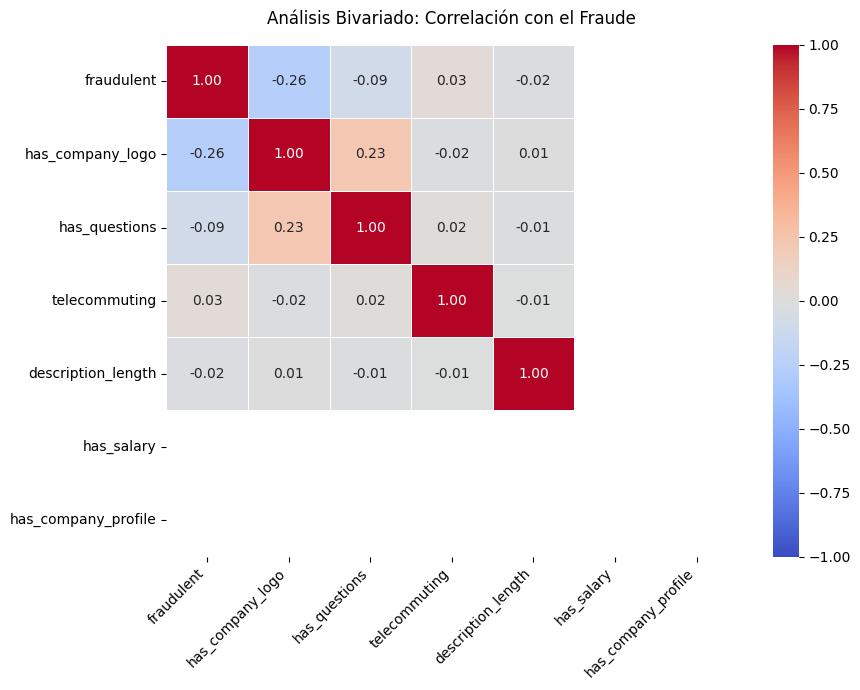

In [18]:
# 3. Tu Heatmap de correlaciones ordenado por relevancia
columnas_bivariado = [
    'fraudulent', 'telecommuting', 'has_company_logo', 
    'has_questions', 'description_length', 'has_salary', 'has_company_profile'
]

df_analisis = df[columnas_bivariado]
matriz_corr = df_analisis.corr()
top_variables = matriz_corr['fraudulent'].abs().sort_values(ascending=False).index

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_analisis[top_variables].corr(), 
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1      
)
plt.title('Análisis Bivariado: Correlación con el Fraude', fontsize=12, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

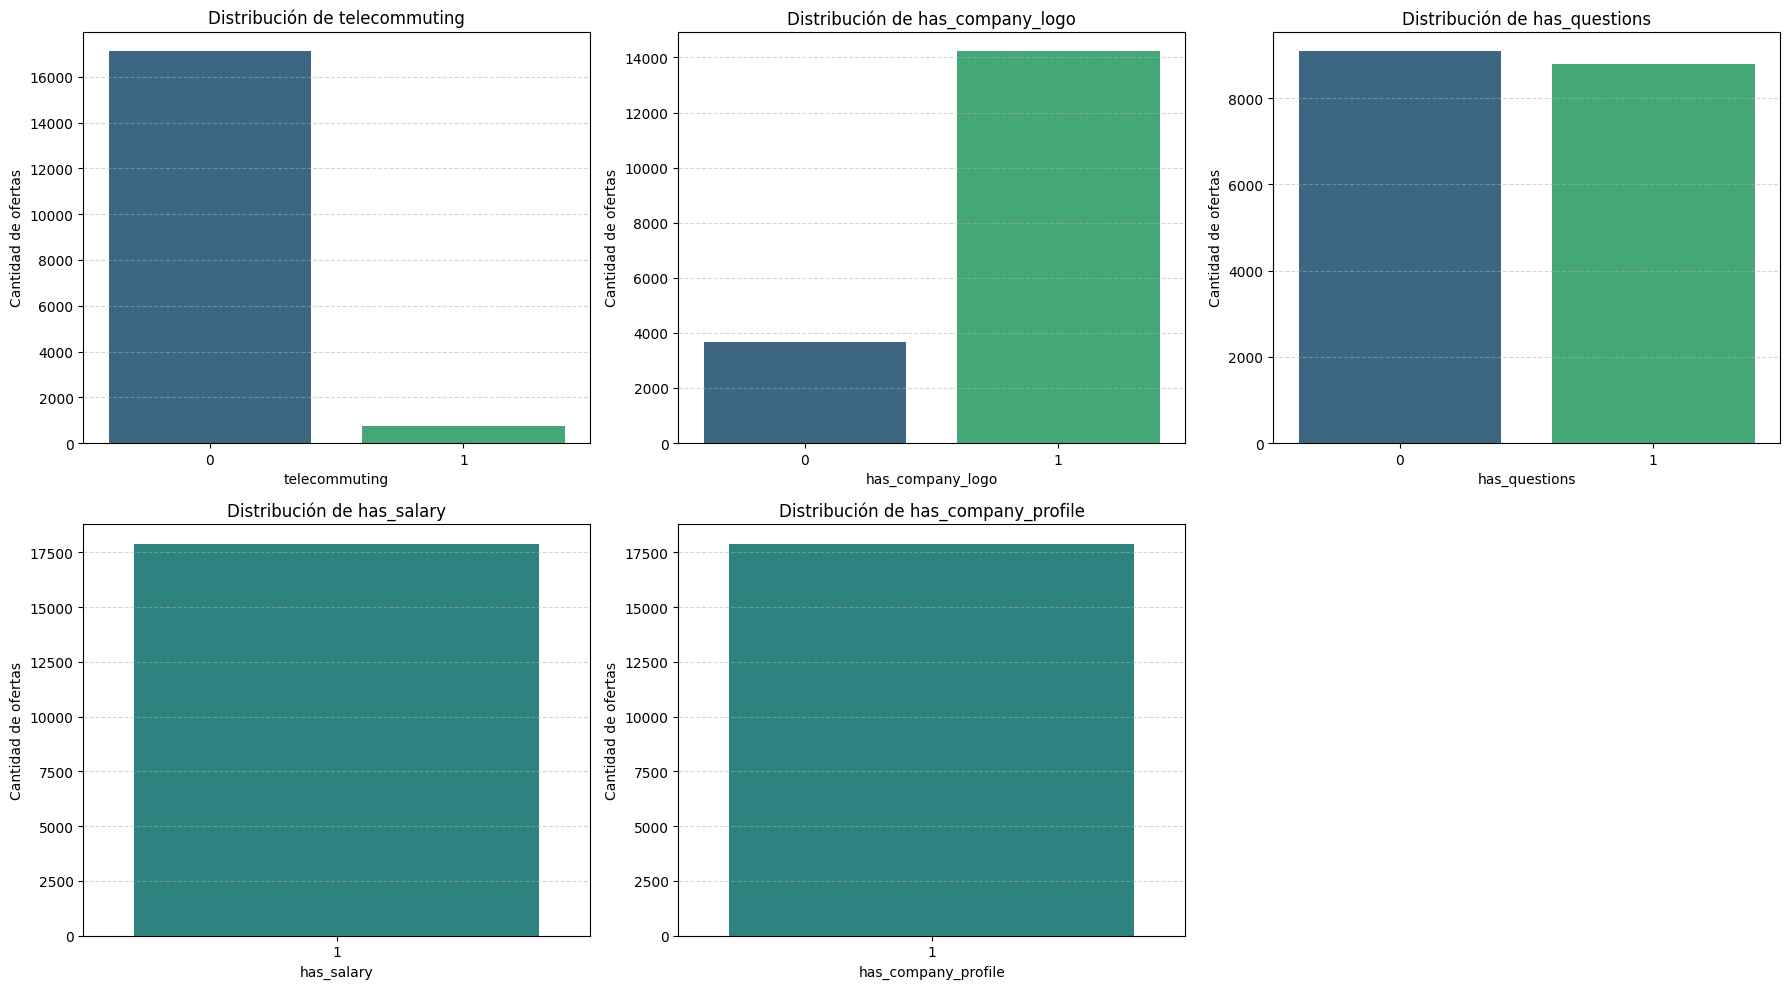

In [19]:
# 1. Definimos la lista con las variables binarias exactas de vuestro proyecto
variables_binarias = [
    'telecommuting', 
    'has_company_logo', 
    'has_questions', 
    'has_salary', 
    'has_company_profile'
]

# 2. Creamos una cuadrícula de 2 filas y 3 columnas (espacio para 6 gráficos)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Convertimos la matriz de ejes en una lista plana para iterar fácilmente (.flatten())
axes = axes.flatten()

# 3. Iteramos para pintar cada una de tus variables binarias
for i, col in enumerate(variables_binarias):
    sns.countplot(
        x=col, 
        data=df, 
        ax=axes[i], 
        palette='viridis',
        hue=col,       # Añadido para cumplir con las nuevas versiones de Seaborn
        legend=False
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de ofertas')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5) # Líneas de guía sutiles

# 4. Ocultamos el último gráfico sobrante (el sexto espacio vacío) para que quede limpio
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\felix\AppData\Local\Temp\ipykernel_18296\1443413237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_company_logo', y='fraudulent', data=df, palette='coolwarm', errorbar=None)


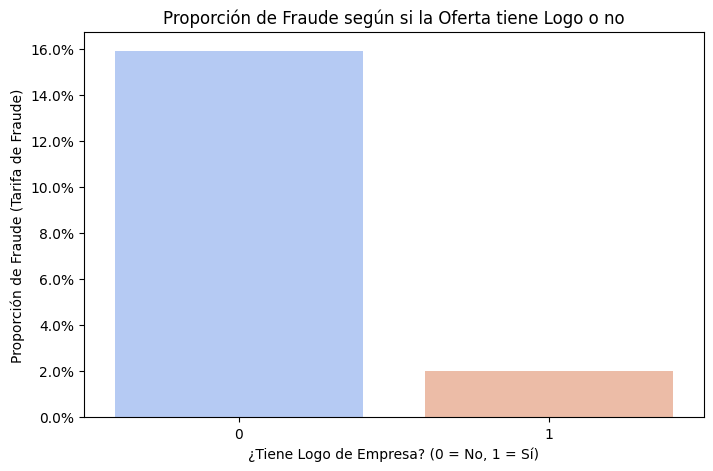

In [20]:
plt.figure(figsize=(8, 5))
# Al calcular la media de una variable 0/1, obtenemos directamente la proporción de fraude (de 0 a 1)
sns.barplot(x='has_company_logo', y='fraudulent', data=df, palette='coolwarm', errorbar=None)
plt.title('Proporción de Fraude según si la Oferta tiene Logo o no')
plt.ylabel('Proporción de Fraude (Tarifa de Fraude)')
plt.xlabel('¿Tiene Logo de Empresa? (0 = No, 1 = Sí)')

# Convertir el eje Y a porcentaje para que el profesor lo entienda mejor
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

C:\Users\felix\AppData\Local\Temp\ipykernel_18296\987795071.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_questions', y='fraudulent', data=df, palette='coolwarm', errorbar=None)


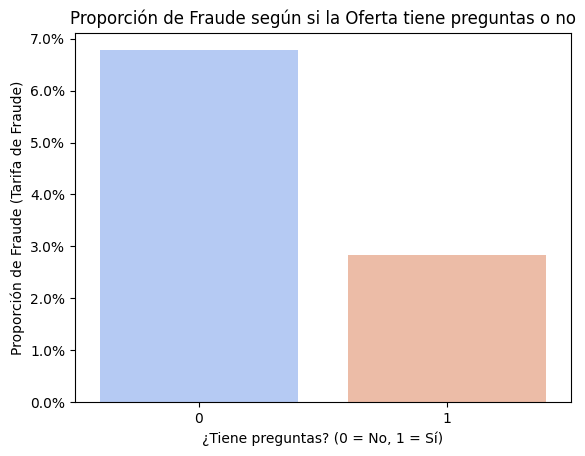

In [21]:
sns.barplot(x='has_questions', y='fraudulent', data=df, palette='coolwarm', errorbar=None)
plt.title('Proporción de Fraude según si la Oferta tiene preguntas o no')
plt.ylabel('Proporción de Fraude (Tarifa de Fraude)')
plt.xlabel('¿Tiene preguntas? (0 = No, 1 = Sí)')

# Convertir el eje Y a porcentaje para que el profesor lo entienda mejor
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

C:\Users\felix\AppData\Local\Temp\ipykernel_18296\2309985699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industrias_top['mean'], y=industrias_top.index, palette='Reds_r')


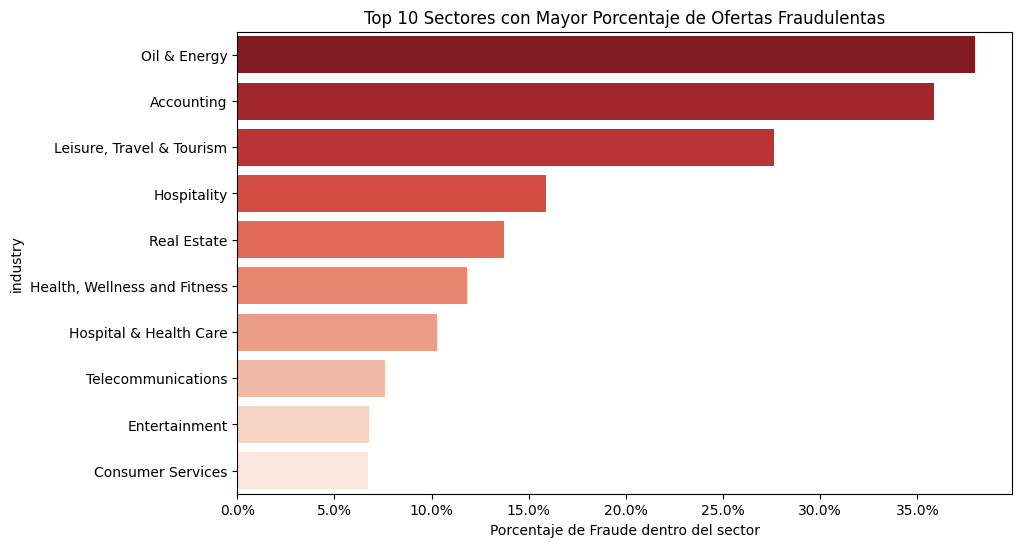

In [22]:
# 1. Agrupamos por industria y calculamos el porcentaje de fraude y el conteo total
analisis_industria = df.groupby('industry')['fraudulent'].agg(['mean', 'count'])

# 2. Filtramos industrias con muy pocas ofertas (por ejemplo, menos de 50) para evitar datos ruidosos
industrias_top = analisis_industria[analisis_industria['count'] > 50].sort_values(by='mean', ascending=False).head(10)

# 3. Pintamos el Top 10 de sectores más peligrosos
plt.figure(figsize=(10, 6))
sns.barplot(x=industrias_top['mean'], y=industrias_top.index, palette='Reds_r')
plt.title('Top 10 Sectores con Mayor Porcentaje de Ofertas Fraudulentas')
plt.xlabel('Porcentaje de Fraude dentro del sector')
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

# **Regresion**

In [25]:
# ==========================================
# 2. INGENIERÍA DE FEATURES PARA EL MODELO
# ==========================================
# Extraemos también el estado y la ciudad de forma segura si 'location' existe
if 'location' in df.columns:
    df['state'] = df['location'].apply(lambda x: str(x).split(',')[1].strip() if pd.notna(x) and len(str(x).split(',')) > 1 else 'Unspecified')
    df['city'] = df['location'].apply(lambda x: str(x).split(',')[2].strip() if pd.notna(x) and len(str(x).split(',')) > 2 else 'Unspecified')
    df.drop(columns=['location'], inplace=True, errors='ignore')

# Creamos métricas numéricas del texto
df['text_length'] = df['description_clean'].apply(len)
df['has_requirements'] = df['requirements'].apply(lambda x: 0 if x == 'Unspecified' else 1)

# Creamos la súper-descripción uniendo tus textos para el NLP de CatBoost
df['full_text'] = df['title'].astype(str) + " " + df['company_profile'].astype(str) + " " + df['description_clean'].astype(str)

# ==========================================
# 3. SELECCIÓN DE VARIABLES Y SPLIT
# ==========================================
# Definimos las columnas que va a usar el modelo
categorical_features = ['country', 'state', 'city', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
numerical_features = ['telecommuting', 'has_company_logo', 'has_questions', 'text_length', 'has_requirements']
text_feature = 'full_text'

# Nos aseguramos de que todas las columnas seleccionadas realmente existan en el DataFrame
categorical_features = [col for col in categorical_features if col in df.columns]
columnas_totales = categorical_features + numerical_features + [text_feature]

X = df[columnas_totales]
y = df['fraudulent']

# Split estratificado para mantener la proporción de fraudes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# 4. CONFIGURACIÓN REGULARIZADA PARA EVITAR OVERFITTING (< 5%)
# ==========================================
# Reducimos el impacto del peso para que las pérdidas no se separen tanto
ratio_suave = np.sqrt(y_train.value_counts()[0] / y_train.value_counts()[1])

model = CatBoostClassifier(
    iterations=1000,             # Le damos más margen ya que el learning_rate es más bajo
    learning_rate=0.015,         # Ritmo más lento y controlado
    depth=3,                     # Árboles extremadamente simples
    l2_leaf_reg=25,              # Penalización L2 muy fuerte
    subsample=0.6,               # Mayor aleatoriedad por árbol
    scale_pos_weight=ratio_suave,
    task_type="CPU",
    cat_features=categorical_features,
    text_features=[text_feature],
    early_stopping_rounds=40,    # Un poco más de paciencia por el learning rate bajo
    verbose=100
)

# Entrenamos el modelo
model.fit(X_train, y_train, eval_set=(X_test, y_test))

# ==========================================
# EVALUACIÓN DE LAS MÉTRICAS DE PÉRDIDA
# ==========================================
# Extraemos las pérdidas finales para calcular el Overfitting exacto ante los profesores
train_loss = model.get_best_score()['learn']['Logloss']
test_loss = model.get_best_score()['validation']['Logloss']
overfitting_porcentaje = ((test_loss - train_loss) / test_loss) * 100

print("\n==========================================")
print(f"📉 Pérdida en Train (Learn): {train_loss:.4f}")
print(f"📉 Pérdida en Test (Validation): {test_loss:.4f}")
print(f"🎯 PORCENTAJE DE OVERFITTING: {overfitting_porcentaje:.2f}%")
print("==========================================\n")

# ==========================================
# 5. EVALUACIÓN FINAL DE PREDICCIONES
# ==========================================
preds = model.predict(X_test)
print("=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, preds))
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, preds))
from sklearn.metrics import roc_auc_score



0:	learn: 0.6859589	test: 0.6859517	best: 0.6859517 (0)	total: 447ms	remaining: 7m 26s
100:	learn: 0.3188996	test: 0.3191886	best: 0.3191886 (100)	total: 18s	remaining: 2m 40s
200:	learn: 0.2584068	test: 0.2493730	best: 0.2493730 (200)	total: 33.5s	remaining: 2m 13s
300:	learn: 0.2261561	test: 0.2151518	best: 0.2151518 (300)	total: 52.9s	remaining: 2m 2s
400:	learn: 0.2021395	test: 0.1918813	best: 0.1918813 (400)	total: 1m 27s	remaining: 2m 11s
500:	learn: 0.1840217	test: 0.1755916	best: 0.1755916 (500)	total: 2m 7s	remaining: 2m 7s
600:	learn: 0.1701606	test: 0.1634582	best: 0.1634582 (600)	total: 2m 38s	remaining: 1m 45s
700:	learn: 0.1579699	test: 0.1534031	best: 0.1534031 (700)	total: 3m 9s	remaining: 1m 20s
800:	learn: 0.1477773	test: 0.1444579	best: 0.1444579 (800)	total: 3m 33s	remaining: 53.1s
900:	learn: 0.1393439	test: 0.1375444	best: 0.1375444 (900)	total: 4m 5s	remaining: 27s
999:	learn: 0.1327565	test: 0.1318924	best: 0.1318924 (999)	total: 4m 49s	remaining: 0us

bestTest 

In [26]:
probs = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", auc)

ROC-AUC: 0.9876528530589297
